# Relaxation and its Role in Vision

# https://era.ed.ac.uk/items/02e3dc47-0325-4574-a4d9-b09c3063b4ee

## Paper Information
- **Title:** Relaxation and its Role in Vision
- **Author:** Geoffrey E. Hinton
- **Type:** Ph.D. Thesis, University of Edinburgh, 1977

## Abstract
The thesis argues that a visual system operating on imperfect data requires a mechanism for selecting the best mutually consistent combination among many interrelated, locally plausible hypotheses about the interpretation of visual input. The author proposes assigning each hypothesis a continuous "supposition value" in the range $$[0,1]$$ and applying a parallel relaxation operator, driven by hypothesis plausibilities and their logical relations, to iteratively adjust these values until the best consistent set converges toward $$1$$ and competing hypotheses toward $$0$$. The method is instantiated in a program that interprets configurations of overlapping rectangles as puppets, extended to guide hypothesis search in more complex tasks, and generalized in an implemented rule-based system (SETTLE) that builds a network of schema instances from input assertions.

## Problems
- Visual interpretation requires forming tentative, mutually interdependent hypotheses about scene structure, since local image data is often locally ambiguous and can only be disambiguated using context.
- Classical hypothesize-and-test approaches assume each hypothesis can be immediately accepted or rejected from local evidence, which fails when disambiguation depends on the surrounding interpretation.
- Existing consistency-finding methods (e.g., Huffman/Clowes labelling, Waltz filtering) can enforce logical consistency among hypotheses but cannot select the *best* interpretation when multiple consistent sets exist, since consistency alone underdetermines the correct interpretation of noisy or ambiguous data.
- Pattern-recognition-style numerical scoring methods were viewed with suspicion in contemporary Artificial Intelligence research, creating a need to justify and formalize the use of explicit numerical scores for resolving complex hypothesis conflicts.
- Search-based optimization methods (e.g., guided depth-first search, branch-and-bound) do not naturally exploit parallel hardware or constraint propagation.

## Proposed Solutions
- **Supposition values and relaxation labelling:** Represent each hypothesis with a continuous numerical value denoting degree of belief, and define numerical constraints between hypotheses derived from their logical relations.
- **Parallel relaxation operator:** An iterative update rule that modifies supposition values based on (a) each hypothesis's individual preference/plausibility score and (b) constraint-violation forces from logically related hypotheses, converging on a feasible and near-optimal (approximately binary) assignment.
- **Two-component operator design:** Separate mechanisms for achieving *feasibility* (satisfying logical constraints) and achieving *optimality* (maximizing the sum of hypothesis scores), combined into a single operator.
- **Relaxation-guided hypothesis generation:** For tasks too large to enumerate all hypotheses in advance, use relaxation on locally plausible hypotheses to control which additional, less-obvious hypotheses ("generators") are created.
- **SETTLE system:** A rule-based architecture in which users define schemas, slots, bonds, and inference rules; the system uses relaxation to determine the best consistent network of schema instances as new assertions arrive, integrating inference with relaxation to avoid forward chaining from premises later rejected.

## Purpose
The thesis investigates whether relaxation labelling is a viable general mechanism for organizing interactions among competing and cooperating hypotheses in vision, replacing purely combinatorial or purely local disambiguation methods with a numerically grounded, parallelizable optimization process. It aims to (1) establish the theoretical presuppositions justifying numerical hypothesis scores, (2) demonstrate the method concretely on constrained visual tasks, (3) analyze its computational properties, and (4) explore its extension toward a general schema-based knowledge representation and inference system.

## Methodology
- **Task design (Chapter 2):** A deliberately simplified test domain—interpreting overlapping transparent rectangles as a puppet figure—chosen to isolate the relaxation mechanism from confounds such as occlusion.
- **Puppet-finding program (Chapter 3):** Constructs candidate hypotheses ("nuclei") about rectangle-to-puppet-part and overlap-to-joint mappings, derives numerical constraints (normalized linear combinations) between supposition values from logical relations, and applies a relaxation operator informed by a hyperspace geometric model; a simplex-algorithm-related formulation is used to assign preferences to hypotheses.
- **Theoretical analysis (Chapter 4):** Examines avoidance of explicit enumeration, decomposition into interacting sub-systems, convergence time to equilibrium, introduction of non-linearity, intermediate-level hypotheses, "weak rules," relaxation-guided hypothesis creation, and optimization of real-valued parameters.
- **Comparative evaluation (Chapter 5):** Compares the linear-programming (L.P.) relaxation approach against alternative contemporary systems, including Rosenfeld, Hummel and Zucker (1975); Yakimovsky and Feldman (1973); Barrow and Tenenbaum (1976); island-growing methods; clique-finding matching; and hierarchical synthesis. Includes an application to Huffman/Clowes line labelling to directly contrast relaxation with Waltz filtering.
- **Representational discussion (Chapter 6):** Analyzes the relationship between stored knowledge (schemas/frames) and perceptual representations, critiquing pure model-matching accounts of perception.
- **SETTLE system implementation (Chapter 7):** Demonstrates schema/rule specification, rule invocation, and network construction through a worked example involving family-relationship claims, including handling of incompatible assertions.

## Results
- The relaxation operator successfully selects the best consistent set of hypotheses in the puppet-finding task, with supposition values converging to approximately $$1$$ (accepted) or $$0$$ (rejected).
- The method handles arbitrary logical constraints expressible in propositional calculus and was successfully applied to both the puppet-finding task and Huffman/Clowes line labelling.
- Analysis identified persistent open problems: selecting between equally good rival global interpretations, handling non-integer optima at constraint-polytope vertices, reducing convergence time, and determining a stopping criterion near equilibrium; a coefficient $$K$$ (Section 4.4) was found to influence all of these qualitatively, though its quantitative effects remained only partially investigated.
- Relaxation-guided hypothesis creation was demonstrated on an extended version of the puppet task, showing the method can control which hypotheses are generated, not just select among pre-existing ones.
- The SETTLE system was implemented and demonstrated on a family-relationships example but encountered unresolved difficulties when applied to more realistic (Popeye-picture) interpretation tasks, limiting full evaluation of its practical value.
- No empirical evidence from human vision was collected; the correspondence between relaxation and biological visual processing remains an open, unaddressed question.

## Conclusions
- A relaxation-based method for selecting the best consistent set of hypotheses was clearly defined, does not appear to suffer from combinatorial explosion in time or space as hypothesis count grows, and can exploit parallel hardware—offering one of the first well-defined mechanisms for organizing parallel interaction among conflicting and cooperating hypotheses to produce a coherent global ("Gestalt") interpretation.
- The approach's validity depends on three contested presuppositions: that tentative hypotheses must be formulated and selected among; that inconsistency alone cannot explain human-like interpretation; and that numerical scoring with sum-maximization is a sensible way to resolve complex hypothesis conflicts—the third being the most contested within the contemporary AI community.
- The work establishes relaxation as a viable computational technique for constrained visual interpretation and as a general mechanism (via SETTLE) for data-driven construction of relational networks under inference rules, but stops short of validating the approach against human perceptual data or fully resolving several theoretical and algorithmic difficulties (non-integer optima, convergence speed, equal-rival resolution).
- The thesis positions relaxation labelling as a foundational precursor to later parallel constraint-satisfaction and connectionist approaches, explicitly framing open questions—particularly the temporal structure of vision (primal sketch vs. cognitive map) and the biological plausibility of relaxation—as directions for future work.

# Mathematical & Statistical Content of "Relaxation and its Role in Vision"

Although this is a vision/AI thesis rather than a pure mathematics paper, it builds its central method on a specific set of mathematical ideas: 0-1 linear programming, probability theory, convex geometry, gradient-based iterative optimization, and a little discrete/combinatorial geometry. Below is each piece, explained simply, with its role in the argument.

---

## 1. The optimization problem: 0-1 (zero-one) Linear Programming

**Idea:** Every hypothesis about the scene (e.g. "this rectangle is an arm") is treated as a binary unknown that is either true (1) or false (0). Each hypothesis has a numerical "preference" score, and the best overall interpretation is the one that maximizes the total score of all accepted hypotheses, subject to logical consistency constraints.

$$
\text{maximize} \sum_i c_i x_i \quad \text{subject to logical/numerical constraints}, \quad x_i \in \{0,1\}
$$

**Role in paper:** This reframes "finding the best scene interpretation" as a classic operations-research problem — a 0-1 (integer) linear program — so that tools from optimization theory can be brought to bear.

---

## 2. Probability as justification for numerical scores

**Idea:** If each hypothesis $h$ is assigned a cost equal to $-\log P(h)$, and hypotheses are treated as independent, then minimizing the sum of costs is mathematically equivalent to maximizing the product of probabilities — i.e., finding the most probable overall interpretation:

$$
\text{minimize} \sum_i -\log P(h_i) \quad \Longleftrightarrow \quad \text{maximize} \prod_i P(h_i)
$$

**Role in paper:** This is used (Section 1.7.1) as the philosophical/mathematical justification for why it's reasonable to add up individual hypothesis scores at all — the log-probability trick converts a multiplicative combination rule into an additive one, which is what the optimization needs.

---

## 3. Supposition values as a relaxed (continuous) version of truth values

**Idea:** Instead of restricting each hypothesis to strictly 0 or 1, the method relaxes them to continuous values in $[0,1]$ — a "supposition value" $S_h$. This is the same trick used in modern LP relaxations of integer programs: solve the easier continuous problem, then push the solution toward integer corners.

**Encoding logical relations numerically:**

- Negation: $S_{\bar{a}} = 1 - S_a$
- Disjunction ($a \lor b \lor c$): $S_a + S_b + S_c \geq 1$

Any propositional formula can be converted to conjunctive normal form and then "cashed" (translated) clause-by-clause into linear inequalities of this kind.

**Role in paper:** This is the core translation step that turns a logic problem (which hypotheses are jointly consistent) into a linear-algebra problem (which points in a continuous space satisfy a set of linear inequalities).

---

## 4. Normalized linear combinations and convex hulls

**Idea:** A linear combination of vectors $V_1, \dots, V_n$ with weights $w_i$ is $\sum w_i V_i$; it is normalized if $\sum w_i = 1$. If every feasible continuous state can be written as a normalized linear combination (a weighted average) of the feasible all-integer states, then the feasible region is exactly the convex hull of the integer solutions.

**Total preference of a mixed state:**

$$
T_S = \sum_i w_i C_i
$$

where $C_i$ is the score of integer state $i$.

**Role in paper:** This is the key theoretical guarantee: if the constraints are chosen strongly enough that the feasible polyhedron's vertices are all integer points, then simple hill-climbing on the continuous relaxation cannot get stuck at a non-integer or spurious local optimum — because there are no local maxima strictly inside a convex polytope for a linear objective; the optimum is always at a vertex.

---

## 5. The hyperspace (geometric) model

**Idea:** Represent the vector of all supposition values as a point in a multidimensional space. Each numerical constraint (inequality) defines a hyperplane, and the region satisfying all constraints is a convex polyhedron. The total score is the dot (scalar) product of a fixed "preference vector" with the state vector:

$$
\text{Score}(S) = \vec{c} \cdot \vec{S}
$$

Maximizing this is equivalent to moving as far as possible in the direction $\vec{c}$ — geometrically, the optimum lies at the polyhedron's vertex that is "furthest" in that direction.

**Role in paper:** This geometric picture underlies almost everything that follows — the relaxation operator is literally described as forces pushing a point around inside/near this polyhedron toward the optimal vertex.

---

## 6. Non-integer optima and cutting planes

**Idea:** Sometimes the "obvious" linear inequalities derived from logical constraints define a polyhedron whose best vertex is *not* an integer point — a "bad vertex." Example given: three mutually exclusive hypotheses $a, b, c$ with constraints $a\bar{b}$, $b\bar{c}$, $c\bar{a}$ ("not both") give:

$$
S_a + S_b \leq 1, \quad S_b + S_c \leq 1, \quad S_c + S_a \leq 1
$$

whose best feasible (non-integer) point is $S_a = S_b = S_c = \tfrac{1}{2}$, with score $1.5$ — better than any real (integer) solution.

**Fix — a "cutting plane":** Add a stronger, logically valid inequality (here $S_a + S_b + S_c \leq 1$) that slices off the fractional vertex without removing any integer solutions. The paper cites Gomory's (1958) theorem guaranteeing that a finite sequence of such cuts always eventually removes all bad vertices.

**Alternative — branch-and-bound:** Split the problem into two subproblems by fixing one fractional variable to 0 or to 1, recursively, discarding branches whose best possible score is already worse than a known integer solution.

**Role in paper:** This addresses a fundamental weakness of continuous relaxation (fractional, uninterpretable "half-true" hypotheses) using standard integer-programming machinery.

---

## 7. The Simplex Algorithm

**Idea:** A textbook method (Dantzig; cited via Pierre 1969) for finding the optimal vertex of a linear-programming polyhedron: start at any vertex, repeatedly move to an adjacent, better vertex (adjacent vertices share all but one bounding hyperplane), and stop when no neighbor improves the score.

**Role in paper:** Used as a benchmark/comparison method. The author notes it is guaranteed correct but is inherently serial (one vertex at a time) and can require an exponential number of steps in the worst case — motivating the search for a genuinely parallel alternative (the relaxation operator).

---

## 8. The relaxation operator as constrained gradient descent

**Infeasibility as a potential-energy function:**

$$
I = \sum_j V_j^2
$$

where $V_j$ is the amount by which constraint $j$ is violated (zero if satisfied). This is mathematically like a spring-based penalty function or a sum-of-squared-residuals loss.

**Gradient/force interpretation:** The rate of change of $I$ with respect to a violation is $\partial I / \partial V_j \propto V_j$ — interpreted as a "force" pulling the state toward the feasible region, analogous to a physical potential-energy gradient.

**Update rule** (steepest descent with step size $K_f$):

$$
S_i^{t+1} = S_i^{t} + K_f \left( \frac{\partial I}{\partial S_i} \right)^{t}
$$

**Convergence theorem** (Section 3.14–3.15): The author proves that for any finite constraint set there exists a finite $K_f$ such that each iteration reduces infeasibility by at least a fixed proportion, guaranteeing exponential decay of infeasibility toward zero over iterations — analogous to a contraction-mapping convergence argument.

**Role in paper:** This turns "satisfy the constraints" into a physically-motivated, parallelizable numerical iteration rather than a symbolic search — each hypothesis updates simultaneously based only on local constraint violations.

---

## 9. Adding the optimization force

Once near-feasible, a constant "preference force" (proportional to $K_p$) is added, pulling the state along the preference vector direction, trading off feasibility against score. The paper shows empirically and geometrically that larger $K_p$ speeds convergence but moves the final equilibrium further from the true optimal vertex — a speed/accuracy trade-off analogous to step-size choices in gradient methods.

---

## 10. Time-to-equilibrium bound (a geometric convergence theorem)

**Idea:** The author proves an explicit upper bound on the number of iterations to reach near-optimality:

$$
t_{SB} \leq \frac{1}{k} \cdot \frac{\sqrt{n}}{\cos \phi}
$$

where $n$ is the number of hypotheses (dimensions), $\phi$ is the angle of the shallowest "ridge" of the polyhedron relative to the preference direction, and $k$ relates to the rate of travel.

**Key result:** Because both the numerator ($\sqrt{n}$, from the hypercube diagonal) and the effective force magnitude $k$ scale together as more (independent) hypotheses are added, the convergence time stays constant as the problem size grows — i.e., relaxation (on parallel hardware) does not suffer the exponential blow-up that serial search methods do.

---

## 11. Non-linear force field for symmetry-breaking ($K_h$)

**Idea:** To handle cases with two equally good rival interpretations (a flat "ridge," e.g. the Necker cube ambiguity), an extra radially symmetric force is added, proportional to the point's distance from the center of the hypercube, pointing toward the nearest integer corner:

$$
\text{extra force} \propto \text{distance from hypercube center, directed toward nearest vertex}
$$

**Role in paper:** Breaks ties/symmetry (turns a flat ridge into two separated local optima) and can help push fractional optimal vertices toward integer ones, though the author notes this component was not rigorously analyzed.

---

## 12. Supporting geometric result (Appendix 1): separating-hyperplane argument for convex polygons

**Statement proved:** Two disjoint convex polygons always have a separating line — a border of one polygon that has the other polygon entirely on its far side.

**Role in paper:** This is a discrete/computational-geometry lemma (a special case of the general separating-hyperplane theorem) used purely as an efficient test for whether two rectangles/zones overlap, supporting the low-level geometric bookkeeping of the puppet-finding program.

---

## Summary Table

| Mathematical Tool | Function in the Thesis |
|---|---|
| 0-1 / integer linear programming | Formal statement of "best consistent interpretation" problem |
| Probability & log-costs | Justifies additive scoring of hypotheses |
| Linear inequalities from logic (CNF cashing) | Converts symbolic constraints into numeric ones |
| Convex hull / normalized combinations | Guarantees continuous relaxation solves the discrete problem |
| Hyperspace/polyhedron geometry | Framework for visualizing and analyzing the search |
| Cutting planes (Gomory) & branch-and-bound | Fixes fractional ("non-integer") solutions |
| Simplex algorithm | Baseline serial optimization method for comparison |
| Penalty function $I = \sum V_j^2$ + gradient descent | Defines the parallel relaxation update rule |
| Convergence & time-complexity theorems | Prove relaxation converges and scales well with problem size |
| Radial non-linear force ($K_h$) | Breaks ties between equally good interpretations |
| Separating-line theorem (Appendix 1) | Efficient overlap test between convex shapes |

| # | Key Problem / Research Gap | How This Limits Prior Work | Proposed Solution in This Thesis |
|---|---|---|---|
| 1 | Visual interpretation requires forming tentative, mutually interdependent hypotheses, since local image data is frequently ambiguous | Hypothesize-and-test methods (Roberts 1965; Grape 1973) assume each hypothesis can be accepted/rejected immediately from local evidence, which fails when disambiguation requires broader context | A **supposition value** ($S_h \in [0,1]$) is attached to every hypothesis, allowing tentative, revisable degrees of belief to be held and propagated simultaneously across many interdependent hypotheses |
| 2 | Consistency-based labelling methods can rule out impossible combinations but cannot select the *best* interpretation among several consistent ones | Huffman/Clowes labelling and Waltz (1972) filtering guarantee logical consistency only; they break down when many locally plausible but globally weak labellings survive filtering (Section 1.6.6) | A relaxation operator that combines **logical consistency constraints with explicit numerical preference scores**, selecting the globally highest-scoring consistent set rather than any arbitrary consistent set |
| 3 | Real-valued numerical scoring was viewed with suspicion in AI research due to its poor track record in the pattern-recognition paradigm | Pattern recognition systems (feature-weight classifiers) treat input as an unsegmented whole and cannot express relational/hierarchical structure (Minsky & Papert 1972), discrediting numerical methods generally | Argues numerical scores are not intrinsically tied to feature-weight representations; scores are attached to **structured, relationally-defined hypotheses**, preserving symbolic richness while still enabling principled optimization (Section 1.8) |
| 4 | Search methods for finding the *good* (not merely consistent) global interpretation scale poorly | Guided depth-first search, branch-and-bound, and the Simplex Algorithm are inherently **serial**, with worst-case exponential numbers of steps as hypothesis count grows (Section 3.9) | A **parallel relaxation operator** is proven (Section 4.3) to reach equilibrium in time independent of the number of hypotheses, given parallel hardware, avoiding the serial bottleneck |
| 5 | Continuous relaxation of a 0-1 programming problem can converge to spurious **non-integer ("fractional") optimal vertices** | Naively generalizing logical constraints into linear inequalities does not guarantee the feasible polyhedron's vertices are all integer points, so no prior relaxation-based vision system addressed this systematically | Introduces **cutting planes** (after Gomory 1958) and a **branch-and-bound fallback** to eliminate non-integer optima, plus stronger a priori numerical constraints (Section 3.7–3.8) that avoided the problem entirely in the puppet task |
| 6 | No principled account exists for how logical constraints of arbitrary complexity should be translated into numerical form | Earlier relaxation-style systems (e.g., Rosenfeld, Hummel & Zucker 1975; Marr & Poggio 1976) handle only restricted, domain-specific constraint types | Provides a **general procedure** for converting any propositional-calculus expression (via conjunctive normal form) into linear numerical constraints on supposition values (Section 3.6) |
| 7 | Purely feasibility-driven or purely search-based relaxation cannot resolve **equally good rival interpretations** (e.g., ambiguous figures) | Prior relaxation labelling methods lack a principled mechanism for symmetry-breaking, leaving ambiguous states unresolved or arbitrarily biased | Introduces a **non-linear radial force term ($K_h$)** that perturbs the equilibrium landscape to favor one of several equally scored integer vertices (Section 4.4) |
| 8 | Enumerating all potential hypotheses in advance is computationally infeasible for realistically complex scenes | Prior systems that pre-enumerate all candidate interpretations (or rely on flat, single-level labelling) do not scale beyond toy domains and cannot express hierarchical scene structure | Proposes **relaxation-guided hypothesis creation**, where partial relaxation results drive the incremental generation of new, higher-level hypotheses, avoiding full enumeration (Sections 4.5–4.7) |
| 9 | Hard logical constraints cannot capture human perceptual flexibility, where "weak" rules are sometimes violated for a better overall interpretation | Existing rule-based and constraint-satisfaction systems treat all constraints as strictly binding, unable to model graceful rule-breaking | Introduces **weak, breakable constraints** implemented via extra "rule-violation" hypotheses with associated costs, permitting selective, discrete rule-breaking without partial/graded constraint violation (Section 4.6) |
| 10 | Existing systems conflate perception with rigid, pre-stored model matching, offering no general mechanism for schema-driven, data-driven inference | Frame-based theories (Minsky) and template-matching systems lack a computational mechanism for resolving conflicting instantiations of schemas under incomplete or contradictory input | Implements the **SETTLE system** (Chapter 7), which uses relaxation to control network growth from user-defined schemas and inference rules, integrating forward chaining with hypothesis rejection to avoid propagating false inferences |

In [1]:
# =============================================================================
# EDUCATIONAL REPLICATION
# "Relaxation and Its Role in Vision" — Geoffrey E. Hinton, PhD Thesis,
# University of Edinburgh, 1977.
#
# This notebook cell implements, in simplified but faithful form, the
# thesis's central computational system: a parallel relaxation labelling
# procedure that selects the best globally-consistent interpretation of a
# scene of overlapping rectangles as a puppet, from among many tentative,
# locally-plausible "hypotheses".
#
# IMPORTANT — WHAT THIS IS NOT:
#   - This is NOT a trainable neural network.
#   - There is NO backpropagation, NO autograd, NO torch.optim.
#   - There is NO supervised dataset, NO classification loss, NO accuracy.
#   - PyTorch is used purely as a tensor-computation library (like NumPy),
#     exactly the way the thesis's parallel-hardware relaxation operator
#     would be implemented on vectorised hardware today.
#
# The "supposition value" of a hypothesis is NOT a learned probability and
# NOT a neuron activation trained on data. It is a continuous degree of
# TENTATIVE ACCEPTANCE, between 0 and 1, that is adjusted purely by
# (a) forces that restore logical/numerical CONSISTENCY (feasibility) and
# (b) forces that pull the state toward a higher-scoring interpretation
# (preference/optimality), exactly as described in Hinton (1977), Ch. 3.
# =============================================================================

import math
import random
import itertools
from dataclasses import dataclass, field
from io import BytesIO

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from IPython.display import display, Image as IPImage

In [2]:
# -----------------------------------------------------------------------------
# 0. REPRODUCIBILITY
# -----------------------------------------------------------------------------
SEED = 1977  # the year of the thesis
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# -----------------------------------------------------------------------------
# 1. WHITE VISUALIZATION THEME
# -----------------------------------------------------------------------------
def apply_white_theme():
    """
    Enforce a clean, publication-style, WHITE plotting theme.
    No dark backgrounds are used anywhere in this notebook.
    """
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.titleweight": "bold",
        "axes.grid": True,
        "grid.color": "0.85",
        "grid.linewidth": 0.6,
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "legend.labelcolor": "black",
        "font.size": 9,
    })

apply_white_theme()

In [4]:
# =============================================================================
# 2. GEOMETRY: rotated rectangles, corners, area, overlap (SAT + clipping)
# =============================================================================
#
# WHAT A "HYPOTHESIS" IS (beginner note):
#   A hypothesis is a TENTATIVE guess about what something in the picture
#   might mean — e.g. "rectangle 3 might be an upper arm". The thesis's
#   central claim is that a vision system cannot always decide such guesses
#   in isolation: many guesses must be held simultaneously, compared, and
#   allowed to support or conflict with one another, before a final,
#   globally consistent decision is made.
# =============================================================================

@dataclass
class Rectangle:
    rect_id: int
    cx: float
    cy: float
    w: float
    h: float
    angle_deg: float  # rotation in degrees
    is_distractor: bool = False

    def corners(self) -> np.ndarray:
        """Return the 4 corner points of the (possibly rotated) rectangle."""
        theta = math.radians(self.angle_deg)
        dx, dy = self.w / 2.0, self.h / 2.0
        local = np.array([[-dx, -dy], [dx, -dy], [dx, dy], [-dx, dy]])
        rot = np.array([[math.cos(theta), -math.sin(theta)],
                         [math.sin(theta), math.cos(theta)]])
        world = local @ rot.T + np.array([self.cx, self.cy])
        return world

    def area(self) -> float:
        """Shoelace formula applied to the rectangle's own corners."""
        return polygon_area(self.corners())


def polygon_area(poly: np.ndarray) -> float:
    """Shoelace formula for the (signed) area of a convex polygon."""
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def sutherland_hodgman_clip(subject: np.ndarray, clip: np.ndarray) -> np.ndarray:
    """
    Exact convex polygon clipping (Sutherland-Hodgman).
    Clips `subject` polygon against every edge of the convex `clip` polygon.
    Both polygons are assumed to be given in consistent (CCW) winding order.
    Returns the (possibly empty) intersection polygon.
    """
    def inside(p, a, b):
        # True if point p is on the left (inside) side of directed edge a->b
        return (b[0] - a[0]) * (p[1] - a[1]) - (b[1] - a[1]) * (p[0] - a[0]) >= -1e-9

    def line_intersect(p1, p2, a, b):
        x1, y1 = p1; x2, y2 = p2; x3, y3 = a; x4, y4 = b
        denom = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
        if abs(denom) < 1e-12:
            return p2
        t = ((x1 - x3) * (y3 - y4) - (y1 - y3) * (x3 - x4)) / denom
        return np.array([x1 + t * (x2 - x1), y1 + t * (y2 - y1)])

    output = list(subject)
    clip_n = len(clip)
    for i in range(clip_n):
        a, b = clip[i], clip[(i + 1) % clip_n]
        if not output:
            break
        input_list = output
        output = []
        n = len(input_list)
        for j in range(n):
            cur = input_list[j]
            prev = input_list[j - 1]
            cur_in = inside(cur, a, b)
            prev_in = inside(prev, a, b)
            if cur_in:
                if not prev_in:
                    output.append(line_intersect(prev, cur, a, b))
                output.append(cur)
            elif prev_in:
                output.append(line_intersect(prev, cur, a, b))
    return np.array(output) if output else np.zeros((0, 2))


def ensure_ccw(poly: np.ndarray) -> np.ndarray:
    """Ensure a polygon's vertices are ordered counter-clockwise."""
    x = poly[:, 0]; y = poly[:, 1]
    signed_area = np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))
    return poly if signed_area > 0 else poly[::-1]


def sat_overlap(poly_a: np.ndarray, poly_b: np.ndarray) -> bool:
    """
    Separating Axis Theorem: fast boolean overlap test for two convex
    polygons. This mirrors the thesis's Appendix 1 result that two disjoint
    convex polygons always admit a separating line along one polygon's edge
    normal.
    """
    for poly in (poly_a, poly_b):
        n = len(poly)
        for i in range(n):
            edge = poly[(i + 1) % n] - poly[i]
            axis = np.array([-edge[1], edge[0]])
            norm = np.linalg.norm(axis)
            if norm < 1e-9:
                continue
            axis = axis / norm
            proj_a = poly_a @ axis
            proj_b = poly_b @ axis
            if proj_a.max() < proj_b.min() - 1e-9 or proj_b.max() < proj_a.min() - 1e-9:
                return False  # separating axis found -> disjoint
    return True


def overlap_ratio(rect_a: Rectangle, rect_b: Rectangle) -> float:
    """
    Approximate overlap ratio in [0, 1]: intersection area divided by the
    area of the smaller rectangle. Uses exact Sutherland-Hodgman clipping.
    """
    ca = ensure_ccw(rect_a.corners())
    cb = ensure_ccw(rect_b.corners())
    if not sat_overlap(ca, cb):
        return 0.0
    inter = sutherland_hodgman_clip(ca, cb)
    if len(inter) < 3:
        return 0.0
    inter_area = polygon_area(inter)
    smaller = min(rect_a.area(), rect_b.area())
    return float(inter_area / smaller) if smaller > 1e-9 else 0.0


def relative_orientation(rect_a: Rectangle, rect_b: Rectangle) -> float:
    """Absolute angular difference between two rectangles, in degrees [0,180]."""
    diff = abs(rect_a.angle_deg - rect_b.angle_deg) % 360.0
    return min(diff, 360.0 - diff)


def endpoint_overlap_score(rect_a: Rectangle, rect_b: Rectangle) -> float:
    """
    Heuristic in [0, 1]: how close the overlap centre lies to an endpoint
    of the *longer* rectangle (used to judge whether an overlap plausibly
    depicts a joint, e.g. shoulder or knee, rather than a mid-body overlap).
    """
    longer, shorter = (rect_a, rect_b) if rect_a.area() >= rect_b.area() else (rect_b, rect_a)
    theta = math.radians(longer.angle_deg)
    axis = np.array([math.cos(theta), math.sin(theta)])
    rel = np.array([shorter.cx - longer.cx, shorter.cy - longer.cy])
    proj = np.dot(rel, axis)
    half_len = max(longer.w, longer.h) / 2.0
    if half_len < 1e-6:
        return 0.0
    normalized = abs(abs(proj) - half_len) / half_len
    return float(max(0.0, 1.0 - normalized))

In [5]:
# =============================================================================
# 3. PUPPET PART / JOINT VOCABULARY
# =============================================================================

PART_TYPES = [
    "head", "neck", "trunk",
    "upper_arm", "lower_arm", "hand",
    "thigh", "calf", "foot",
]

JOINT_TYPES = [
    "head_neck", "neck_trunk", "trunk_upper_arm", "upper_arm_lower_arm",
    "lower_arm_hand", "trunk_thigh", "thigh_calf", "calf_foot",
]

# Which part must precede which part along a limb (used to build joints).
JOINT_PART_PAIRS = {
    "head_neck": ("head", "neck"),
    "neck_trunk": ("neck", "trunk"),
    "trunk_upper_arm": ("trunk", "upper_arm"),
    "upper_arm_lower_arm": ("upper_arm", "lower_arm"),
    "lower_arm_hand": ("lower_arm", "hand"),
    "trunk_thigh": ("trunk", "thigh"),
    "thigh_calf": ("thigh", "calf"),
    "calf_foot": ("calf", "foot"),
}


@dataclass
class Hypothesis:
    """A candidate interpretation of ONE rectangle as ONE puppet part."""
    hypothesis_id: int
    rectangle_id: int
    part_type: str
    orientation: str  # "left", "right", or "none"
    preference: float
    supposition_value: float = 0.0


@dataclass
class JointHypothesis:
    """A candidate interpretation of an OVERLAP as a joint between two parts."""
    joint_id: int
    first_part_hypothesis: int   # index into hypothesis list
    second_part_hypothesis: int  # index into hypothesis list
    joint_type: str
    preference: float
    supposition_value: float = 0.0

In [6]:
# =============================================================================
# 4. SYNTHETIC SCENE GENERATOR (replaces CIFAR-10)
# =============================================================================
#
# CIFAR-10 is NOT used: the thesis's system does not operate on natural
# photographic categories. It operates on EXPLICIT geometric rectangles and
# SYMBOLIC candidate hypotheses about how those rectangles might depict the
# parts of a puppet. We therefore build five small synthetic scenes.
# =============================================================================

@dataclass
class Scene:
    name: str
    description: str
    rectangles: list = field(default_factory=list)
    user_preferences: dict = field(default_factory=dict)  # rect_id -> forced part


def make_rect(rid, cx, cy, w, h, angle, distractor=False):
    return Rectangle(rid, cx, cy, w, h, angle, distractor)


def build_scenes():
    scenes = []

    # --- Scene 1: simple valid partial puppet (head-neck-trunk-arm-leg) ---
    r = [
        make_rect(0, 0.0, 6.0, 1.2, 1.2, 0),     # head
        make_rect(1, 0.0, 4.6, 0.6, 1.4, 0),     # neck
        make_rect(2, 0.0, 2.5, 2.4, 3.0, 0),     # trunk
        make_rect(3, -1.6, 2.8, 1.6, 0.6, 20),   # upper arm (right on canvas)
        make_rect(4, -2.9, 2.4, 1.6, 0.55, 60),  # lower arm
        make_rect(5, -3.9, 2.0, 0.7, 0.7, 0),    # hand
        make_rect(6, 0.9, 0.7, 0.7, 1.8, 5),     # thigh
        make_rect(7, 1.0, -1.2, 0.6, 1.8, 0),    # calf
        make_rect(8, 1.0, -2.6, 0.8, 0.5, 0),    # foot
    ]
    scenes.append(Scene("simple_partial_puppet",
                         "A clean, unambiguous partial puppet: one head, "
                         "one arm chain, one leg chain.", r))

    # --- Scene 2: rival hand/foot interpretations at an arm/leg endpoint ---
    r = [
        make_rect(0, 0.0, 6.0, 1.2, 1.2, 0),
        make_rect(1, 0.0, 4.6, 0.6, 1.4, 0),
        make_rect(2, 0.0, 2.5, 2.4, 3.0, 0),
        make_rect(3, -1.6, 2.8, 1.6, 0.6, 20),
        make_rect(4, -2.9, 2.4, 1.6, 0.55, 60),
        # This small endpoint rectangle is geometrically ambiguous:
        # it could be read as a hand (arm branch) OR a foot (leg branch).
        make_rect(5, -3.9, 2.0, 0.7, 0.7, 0),
    ]
    scenes.append(Scene("rival_hand_foot",
                         "The terminal rectangle admits RIVAL 'hand' and "
                         "'foot' hypotheses that compete for the same "
                         "supposition mass.", r))

    # --- Scene 3: distractor rectangles unrelated to the puppet ---
    r = [
        make_rect(0, 0.0, 6.0, 1.2, 1.2, 0),
        make_rect(1, 0.0, 4.6, 0.6, 1.4, 0),
        make_rect(2, 0.0, 2.5, 2.4, 3.0, 0),
        make_rect(3, -1.6, 2.8, 1.6, 0.6, 20),
        make_rect(4, -2.9, 2.4, 1.6, 0.55, 60),
        make_rect(5, -3.9, 2.0, 0.7, 0.7, 0),
        make_rect(6, 0.9, 0.7, 0.7, 1.8, 5),
        make_rect(7, 1.0, -1.2, 0.6, 1.8, 0),
        make_rect(8, 1.0, -2.6, 0.8, 0.5, 0),
        # distractors: floating, non-overlapping / irrelevant rectangles
        make_rect(9, 6.0, 6.0, 0.9, 0.9, 45, distractor=True),
        make_rect(10, 6.0, 4.0, 0.5, 2.0, 10, distractor=True),
    ]
    scenes.append(Scene("distractor_rectangles",
                         "Two irrelevant distractor rectangles are added; "
                         "they must NOT be absorbed into the final puppet "
                         "interpretation.", r))

    # --- Scene 4: one missing part (no lower-arm/hand for one arm) ---
    r = [
        make_rect(0, 0.0, 6.0, 1.2, 1.2, 0),
        make_rect(1, 0.0, 4.6, 0.6, 1.4, 0),
        make_rect(2, 0.0, 2.5, 2.4, 3.0, 0),
        make_rect(3, -1.6, 2.8, 1.6, 0.6, 20),  # upper arm present
        # lower_arm / hand intentionally OMITTED
        make_rect(6, 0.9, 0.7, 0.7, 1.8, 5),
        make_rect(7, 1.0, -1.2, 0.6, 1.8, 0),
        make_rect(8, 1.0, -2.6, 0.8, 0.5, 0),
    ]
    scenes.append(Scene("missing_part",
                         "A lower-arm/hand chain is missing entirely; the "
                         "system must not hallucinate a hypothesis for "
                         "geometry that was never presented.", r))

    # --- Scene 5: two similarly-good global interpretations (ambiguous) ---
    r = [
        make_rect(0, 0.0, 6.0, 1.2, 1.2, 0),
        # Two nearly-symmetric candidate necks under the head -- an
        # intentionally ambiguous configuration akin to a Necker-cube-style
        # rival pair discussed in the thesis (Section 4.4).
        make_rect(1, -0.15, 4.6, 0.6, 1.4, -6),
        make_rect(11, 0.15, 4.6, 0.6, 1.4, 6),
        make_rect(2, 0.0, 2.5, 2.4, 3.0, 0),
    ]
    scenes.append(Scene("ambiguous_two_rivals",
                         "Two overlapping neck candidates are almost "
                         "equally good; relaxation may settle near a "
                         "50/50 ridge unless polarization breaks the tie.",
                         r))

    return scenes


SCENES = build_scenes()

In [7]:
# =============================================================================
# 5. CANDIDATE-HYPOTHESIS GENERATION (Stage A: nuclei, Stage B: growth)
# =============================================================================
#
# NOTE (faithfulness to the thesis): relaxation SELECTS among existing
# hypotheses; it does NOT invent hypotheses that were never generated here.
# If a part was never proposed in Stage A/B, no amount of relaxation can
# recover it. This mirrors Hinton (1977), Section 8.6.
# =============================================================================

def overlaps_of(rect_id, rects, ratio_threshold=0.03):
    """Return list of (other_rect_id, overlap_ratio) for a given rectangle."""
    out = []
    this = next(r for r in rects if r.rect_id == rect_id)
    for other in rects:
        if other.rect_id == rect_id:
            continue
        ratio = overlap_ratio(this, other)
        if ratio > ratio_threshold:
            out.append((other.rect_id, ratio))
    return out


def generate_hypotheses(scene: Scene):
    """
    Stage A: create local 'nuclei' hypotheses using simplified geometric
    rules echoing Hinton (1977) Section 3.2.1.
    Stage B: grow related part/joint hypotheses from those nuclei until no
    new hypotheses are produced (Section 3.2).
    """
    rects = scene.rectangles
    hyps: list[Hypothesis] = []
    joints: list[JointHypothesis] = []

    def add_hypothesis(rect_id, part_type, orientation, base_pref):
        # Avoid exact duplicates (same rectangle + same part type).
        for h in hyps:
            if h.rectangle_id == rect_id and h.part_type == part_type:
                return h
        pref = base_pref
        forced = scene.user_preferences.get(rect_id)
        if forced == part_type:
            pref += 2.0  # user-supplied importance boost
        h = Hypothesis(len(hyps), rect_id, part_type, orientation, pref)
        hyps.append(h)
        return h

    overlap_cache = {r.rect_id: overlaps_of(r.rect_id, rects) for r in rects}

    # ---- Stage A: nuclei -----------------------------------------------
    for r in rects:
        if r.is_distractor:
            continue
        my_overlaps = overlap_cache[r.rect_id]

        # Rule 1: single-overlap, wider-than-partner -> candidate head.
        if len(my_overlaps) == 1:
            (other_id, ratio) = my_overlaps[0]
            other = next(x for x in rects if x.rect_id == other_id)
            if r.area() > other.area() and r.w * r.h < other.w * other.h * 1.5:
                base = 1.0 + endpoint_overlap_score(r, other)
                add_hypothesis(r.rect_id, "head", "none", base)

        # Rule 2: single-overlap, smaller-than-partner -> rival hand/foot.
        if len(my_overlaps) == 1:
            (other_id, ratio) = my_overlaps[0]
            other = next(x for x in rects if x.rect_id == other_id)
            if r.area() < other.area():
                base = 0.8 + endpoint_overlap_score(r, other)
                add_hypothesis(r.rect_id, "hand", "none", base)
                add_hypothesis(r.rect_id, "foot", "none", base)

        # Rule 3: three-or-more narrower overlaps -> candidate trunk.
        narrower = [oid for oid, ratio in my_overlaps
                    if next(x for x in rects if x.rect_id == oid).area() < r.area()]
        if len(narrower) >= 2:
            add_hypothesis(r.rect_id, "trunk", "none", 1.5)

    # ---- Stage B: grow related hypotheses --------------------------------
    changed = True
    guard = 0
    while changed and guard < 25:
        changed = False
        guard += 1
        current_hyps = list(hyps)  # snapshot to avoid mutating while iterating
        for h in current_hyps:
            r = next(x for x in rects if x.rect_id == h.rectangle_id)
            for other_id, ratio in overlap_cache[h.rectangle_id]:
                other = next(x for x in rects if x.rect_id == other_id)
                if other.is_distractor:
                    continue
                # Try every joint type whose first slot matches h.part_type.
                for jt, (p_from, p_to) in JOINT_PART_PAIRS.items():
                    if h.part_type != p_from:
                        continue
                    orient_ok = endpoint_overlap_score(r, other) > 0.05
                    if not orient_ok:
                        continue
                    # Create (or find) the target part hypothesis on `other`.
                    existing = [x for x in hyps
                                if x.rectangle_id == other_id and x.part_type == p_to]
                    if existing:
                        target = existing[0]
                        is_new_part = False
                    else:
                        base = 0.6 + endpoint_overlap_score(r, other)
                        target = add_hypothesis(other_id, p_to, "none", base)
                        is_new_part = True
                        changed = True
                    # Create the joint hypothesis if it doesn't exist yet.
                    dup = any(j.first_part_hypothesis == h.hypothesis_id and
                              j.second_part_hypothesis == target.hypothesis_id and
                              j.joint_type == jt for j in joints)
                    if not dup:
                        jpref = 1.0 * endpoint_overlap_score(r, other)
                        joints.append(JointHypothesis(
                            len(joints), h.hypothesis_id, target.hypothesis_id,
                            jt, jpref))
                        changed = True
    return hyps, joints

In [8]:
# =============================================================================
# 6. SUPPOSITION NODES, CONSTRAINTS (A @ s >= b), AND PREFERENCES
# =============================================================================
#
# A "supposition value" is a continuous number in [0,1] denoting HOW MUCH a
# hypothesis is currently being tentatively supposed to be correct. It is
# NOT a probability learned from data and NOT a neuron trained by gradient
# descent: it is adjusted purely by explicit feasibility/preference forces.
# =============================================================================

@dataclass
class ConstraintSet:
    A: torch.Tensor            # (num_constraints, num_vars)
    b: torch.Tensor            # (num_constraints,)
    names: list
    explanations: list
    categories: list
    num_equalities: int


def build_constraints(hyps, joints):
    """
    Build all A @ s >= b inequalities, s = concat(part_supposition,
    joint_supposition). Equalities aTs = c are expanded into two
    inequalities as required by Section 9 of the specification.
    """
    n_parts = len(hyps)
    n_joints = len(joints)
    n = n_parts + n_joints

    rows_A = []
    rows_b = []
    names = []
    explanations = []
    categories = []
    n_eq = 0

    def add_ineq(coeffs: dict, bound: float, name: str, explanation: str, category: str):
        row = np.zeros(n)
        for idx, c in coeffs.items():
            row[idx] += c
        rows_A.append(row)
        rows_b.append(bound)
        names.append(name)
        explanations.append(explanation)
        categories.append(category)

    def add_eq(coeffs: dict, bound: float, name: str, explanation: str, category: str):
        nonlocal n_eq
        add_ineq(coeffs, bound, name + "_ge", explanation + " (>=)", category)
        neg = {k: -v for k, v in coeffs.items()}
        add_ineq(neg, -bound, name + "_le", explanation + " (<=, via negation)", category)
        n_eq += 1

    # --- B. Rival interpretations of one rectangle: sum(rivals) <= 1 -----
    by_rect = {}
    for h in hyps:
        by_rect.setdefault(h.rectangle_id, []).append(h)
    for rect_id, group in by_rect.items():
        if len(group) > 1:
            coeffs = {h.hypothesis_id: -1.0 for h in group}  # -sum >= -1
            add_ineq(coeffs, -1.0,
                      f"rival_rect_{rect_id}",
                      f"Rectangle {rect_id}: sum of rival part hypotheses <= 1",
                      "rival_interpretation")

    # --- C. Joint implies its parts: s_j <= s_p  and  s_j <= s_q ---------
    for j in joints:
        j_idx = n_parts + j.joint_id
        add_ineq({j_idx: -1.0, j.first_part_hypothesis: 1.0}, 0.0,
                  f"joint_{j.joint_id}_implies_p1",
                  f"Joint {j.joint_id} ({j.joint_type}) requires its first part hypothesis",
                  "joint_implies_parts")
        add_ineq({j_idx: -1.0, j.second_part_hypothesis: 1.0}, 0.0,
                  f"joint_{j.joint_id}_implies_p2",
                  f"Joint {j.joint_id} ({j.joint_type}) requires its second part hypothesis",
                  "joint_implies_parts")

    # --- F. One slot, one occupant: competing joints into the same target
    #        part hypothesis must sum to <= 1 --------------------------
    by_target_part = {}
    for j in joints:
        by_target_part.setdefault(j.second_part_hypothesis, []).append(j)
    for target, group in by_target_part.items():
        if len(group) > 1:
            coeffs = {n_parts + j.joint_id: -1.0 for j in group}
            add_ineq(coeffs, -1.0,
                      f"one_slot_one_occupant_{target}",
                      f"At most one competing joint may fill the slot on part hypothesis {target}",
                      "one_slot_one_occupant")

    # --- G. Structural rule: a joint cannot connect a hypothesis to itself
    for j in joints:
        assert j.first_part_hypothesis != j.second_part_hypothesis, \
            "A joint cannot connect a hypothesis to itself."

    # --- D. Selected trunk must be supported by at least one child joint
    #        (mandatory-slot example; applied only to 'trunk' parts) -----
    for h in hyps:
        if h.part_type == "trunk":
            supporting = [n_parts + j.joint_id for j in joints
                          if j.first_part_hypothesis == h.hypothesis_id]
            if supporting:
                coeffs = {h.hypothesis_id: -1.0}
                for idx in supporting:
                    coeffs[idx] = coeffs.get(idx, 0.0) + 1.0
                add_ineq(coeffs, 0.0,
                          f"trunk_{h.hypothesis_id}_needs_support",
                          f"Trunk hypothesis {h.hypothesis_id} requires >=1 supporting joint",
                          "requires_support")

    if not rows_A:
        A = torch.zeros((0, n), dtype=torch.float32)
        b = torch.zeros((0,), dtype=torch.float32)
    else:
        A = torch.tensor(np.array(rows_A), dtype=torch.float32)
        b = torch.tensor(np.array(rows_b), dtype=torch.float32)

    return ConstraintSet(A, b, names, explanations, categories, n_eq)


def build_preferences(hyps, joints):
    n_parts = len(hyps)
    n_joints = len(joints)
    f = np.zeros(n_parts + n_joints, dtype=np.float32)
    for h in hyps:
        f[h.hypothesis_id] = h.preference
    for j in joints:
        f[n_parts + j.joint_id] = j.preference
    return torch.tensor(f, dtype=torch.float32)

In [9]:
# =============================================================================
# 7. PARALLEL RELAXATION OPERATOR
# =============================================================================
#
# The state s in [0,1]^n represents ALL supposition values simultaneously.
# At every iteration we compute FOUR forces from the SAME previous state s_t
# and then update every value in parallel (never serially):
#
#   1. Feasibility force  -- pulls s toward satisfying A @ s >= b.
#   2. Preference force   -- pulls s toward higher-scoring hypotheses.
#   3. Polarization force -- pulls s away from the uncertain value 0.5,
#                             increasingly strongly as iterations proceed.
#   4. Inertia force       -- a momentum-like term using the previous change,
#                             which speeds up convergence.
#
# This is a transparent, vectorised (PyTorch-tensor) re-implementation of
# Hinton (1977) Section 3.13-3.19's two-component relaxation operator
# (feasibility component + optimality component), augmented with the
# tie-breaking non-linear force discussed in Section 4.4 (here called the
# "polarization force").
# =============================================================================

NUM_ITERATIONS = 50

RELAX_CONFIG = dict(
    feasibility_rate=0.20,
    preference_rate=0.03,
    initial_polarization_rate=0.00,
    final_polarization_rate=0.08,
    inertia_rate=0.40,
)


def run_relaxation(constraints: ConstraintSet, preferences: torch.Tensor,
                    num_iterations=NUM_ITERATIONS, config=RELAX_CONFIG):
    """
    Runs the parallel relaxation operator and returns a full trajectory of
    diagnostics for visualization. NO autograd, NO optimizer: every update
    is an explicit, hand-written tensor computation.
    """
    A, b = constraints.A.to(DEVICE), constraints.b.to(DEVICE)
    f = preferences.to(DEVICE)
    n = f.shape[0]

    # Normalize each constraint row so that constraints with many non-zero
    # coefficients do not dominate purely because of their size.
    row_norms = torch.clamp(A.norm(dim=1, keepdim=True), min=1e-8)
    A_normalized = A / row_norms
    b_normalized = b / row_norms.squeeze(1)

    # Normalized preference direction (unit vector) for the optimality force.
    f_norm = torch.clamp(f.norm(), min=1e-8)
    preference_direction = f / f_norm

    s = torch.zeros(n, device=DEVICE)
    s_prev = s.clone()

    history = {
        "s": [], "max_violation": [], "mean_violation": [],
        "num_violated": [], "preference_score": [], "change_norm": [],
        "near_zero": [], "near_one": [], "uncertain": [],
        "dist_to_binary": [], "feas_force_norm": [], "pref_force_norm": [],
        "polar_force_norm": [], "inertia_force_norm": [],
        "violation_matrix": [],  # constraints x iterations
    }

    for t in range(num_iterations):
        # --- A. Constraint violation: relu(b - A@s) --------------------
        Asb = A_normalized @ s
        violation = torch.relu(b_normalized - Asb)  # (num_constraints,)

        # --- B. Feasibility force: A^T @ weighted_violations ------------
        feasibility_force = A_normalized.T @ violation
        if feasibility_force.norm() > 1e-8:
            feasibility_force = feasibility_force / torch.clamp(feasibility_force.norm(), min=1.0)

        # --- C. Preference / optimality force ---------------------------
        preference_force = preference_direction

        # --- D. Polarization force: push away from the undecided 0.5 ---
        progress = t / max(1, num_iterations - 1)
        polarization_rate = (
            config["initial_polarization_rate"] +
            max(0.0, progress - 0.5) * 2.0 *
            (config["final_polarization_rate"] - config["initial_polarization_rate"])
        )
        polarization_force = s - 0.5

        # --- E. Inertia / convergence-acceleration term -----------------
        inertia_force = s - s_prev

        # --- F. Parallel update over ALL hypotheses simultaneously ------
        s_next = (
            s
            + config["feasibility_rate"] * feasibility_force
            + config["preference_rate"] * preference_force
            + polarization_rate * polarization_force
            + config["inertia_rate"] * inertia_force
        )
        s_next = torch.clamp(s_next, 0.0, 1.0)

        assert torch.isfinite(s_next).all(), "Non-finite supposition values detected."

        change_norm = (s_next - s).norm().item()

        # ---- bookkeeping / diagnostics ----
        history["s"].append(s_next.detach().cpu().numpy().copy())
        history["max_violation"].append(violation.max().item() if violation.numel() else 0.0)
        history["mean_violation"].append(violation.mean().item() if violation.numel() else 0.0)
        history["num_violated"].append(int((violation > 1e-4).sum().item()))
        history["preference_score"].append((f @ s_next).item())
        history["change_norm"].append(change_norm)
        history["near_zero"].append(int((s_next < 0.05).sum().item()))
        history["near_one"].append(int((s_next > 0.95).sum().item()))
        history["uncertain"].append(int(((s_next >= 0.05) & (s_next <= 0.95)).sum().item()))
        history["dist_to_binary"].append(torch.min(s_next, 1 - s_next).sum().item())
        history["feas_force_norm"].append(feasibility_force.norm().item())
        history["pref_force_norm"].append(preference_force.norm().item())
        history["polar_force_norm"].append((polarization_rate * polarization_force).norm().item())
        history["inertia_force_norm"].append((config["inertia_rate"] * inertia_force).norm().item())
        history["violation_matrix"].append(violation.detach().cpu().numpy().copy())

        s_prev = s
        s = s_next

        # ---- early-stopping check (relaxation iteration, not "epoch") --
        max_v = history["max_violation"][-1]
        if max_v < 1e-3 and change_norm < 1e-4:
            mostly_binary = (history["near_zero"][-1] + history["near_one"][-1]) >= 0.8 * n
            if mostly_binary:
                # We still allow the caller to run the full schedule for
                # visualization; here we simply record that convergence
                # was reached (loop continues for plotting continuity).
                pass

    history["violation_matrix"] = np.array(history["violation_matrix"]).T  # constraints x iters
    return s.detach().cpu().numpy(), history

In [10]:
# =============================================================================
# 8. FINAL HYPOTHESIS SELECTION AND REPAIR
# =============================================================================

def select_and_repair(s_final, constraints: ConstraintSet, preferences: torch.Tensor,
                       n_parts, n_joints, threshold=0.5):
    """
    Threshold the continuous relaxation state, verify constraints, and
    perform a small greedy repair if the threshold produces an infeasible
    discrete interpretation.
    """
    f = preferences.numpy()
    n = n_parts + n_joints
    order = np.argsort(-s_final)  # rank by supposition value, descending

    def is_feasible(binary):
        Av = constraints.A.numpy() @ binary
        return np.all(Av >= constraints.b.numpy() - 1e-6)

    discrete = (s_final >= threshold).astype(np.float32)

    if not is_feasible(discrete):
        # Greedy repair: walk hypotheses in descending supposition order,
        # tentatively accept, keep if still feasible, else reject.
        discrete = np.zeros(n, dtype=np.float32)
        for idx in order:
            if s_final[idx] < threshold:
                continue
            trial = discrete.copy()
            trial[idx] = 1.0
            if is_feasible(trial):
                discrete = trial

    feasible_final = is_feasible(discrete)
    selected = np.where(discrete > 0.5)[0]
    rejected = np.where((discrete <= 0.5) & (s_final < 0.95))[0]
    uncertain = np.where((s_final > 0.05) & (s_final < 0.95))[0]

    selected_parts = [i for i in selected if i < n_parts]
    selected_joints = [i - n_parts for i in selected if i >= n_parts]

    return {
        "discrete": discrete,
        "feasible": feasible_final,
        "selected_parts": selected_parts,
        "selected_joints": selected_joints,
        "rejected": rejected,
        "uncertain": uncertain,
        "preference_score": float(f @ discrete),
    }

In [11]:
# =============================================================================
# 9. EXACT DISCRETE BASELINE (exhaustive enumeration for small scenes)
# =============================================================================

def exact_discrete_search(constraints: ConstraintSet, preferences: torch.Tensor, n_vars):
    """
    Exhaustively enumerate all 2^n binary states when n_vars <= 20 and
    return the best FEASIBLE interpretation, detecting equal-best rivals.
    This is intractable beyond small n, illustrating exactly why the
    thesis's continuous relaxation approach is needed for larger scenes.
    """
    if n_vars > 20:
        return None  # exhaustive search is infeasible; explained to the user

    A = constraints.A.numpy()
    b = constraints.b.numpy()
    f = preferences.numpy()

    best_score = -np.inf
    best_states = []
    for bits in itertools.product([0, 1], repeat=n_vars):
        s = np.array(bits, dtype=np.float32)
        if A.shape[0] > 0 and not np.all(A @ s >= b - 1e-6):
            continue
        score = float(f @ s)
        if score > best_score + 1e-9:
            best_score = score
            best_states = [s]
        elif abs(score - best_score) <= 1e-9:
            best_states.append(s)

    return {
        "best_score": best_score if best_states else None,
        "best_states": best_states,
        "num_equal_rivals": len(best_states),
        "num_states_enumerated": 2 ** n_vars,
    }

In [12]:
# =============================================================================
# 10. OPTIONAL LINE-LABELLING DEMONSTRATION (disabled by default)
# =============================================================================

RUN_LINE_LABELLING_DEMO = False

def line_labelling_demo():
    """
    Small optional demonstration (Hinton 1977, Ch.5.2) of relaxation applied
    to Huffman/Clowes line labelling on a simple triangle junction. Kept
    fully separate from the main puppet experiment and disabled by default.
    """
    labels = ["convex(+)", "concave(-)", "occluding(>)"]
    n_lines = 3
    n_vars = n_lines * len(labels)
    f = torch.ones(n_vars) * 0.1
    rows_A, rows_b = [], []
    # Exactly-one-label constraint per line.
    for li in range(n_lines):
        coeffs = np.zeros(n_vars)
        coeffs[li * len(labels):(li + 1) * len(labels)] = -1.0
        rows_A.append(coeffs); rows_b.append(-1.0)
        coeffs2 = -coeffs
        rows_A.append(coeffs2); rows_b.append(1.0)
    A = torch.tensor(np.array(rows_A), dtype=torch.float32)
    b = torch.tensor(np.array(rows_b), dtype=torch.float32)
    cs = ConstraintSet(A, b, ["excl"] * len(rows_A), ["exactly one label"] * len(rows_A),
                        ["line_labelling"] * len(rows_A), n_lines)
    s_final, hist = run_relaxation(cs, f, num_iterations=30)
    return s_final, hist

if RUN_LINE_LABELLING_DEMO:
    _ = line_labelling_demo()

In [13]:
# =============================================================================
# 11. RUN THE PIPELINE ACROSS ALL FIVE SCENES
# =============================================================================

@dataclass
class ExperimentResult:
    scene: Scene
    hyps: list
    joints: list
    constraints: ConstraintSet
    preferences: torch.Tensor
    s_final: np.ndarray
    history: dict
    selection: dict
    exact: dict


def run_experiment(scene: Scene) -> ExperimentResult:
    hyps, joints = generate_hypotheses(scene)
    n_parts, n_joints = len(hyps), len(joints)
    constraints = build_constraints(hyps, joints)
    preferences = build_preferences(hyps, joints)

    # ---- sanity checks (Section 20) ----
    n_vars = n_parts + n_joints
    assert constraints.A.shape[1] == n_vars, "Constraint matrix / hypothesis vector mismatch."
    for j in joints:
        assert j.first_part_hypothesis != j.second_part_hypothesis
        assert 0 <= j.first_part_hypothesis < n_parts
        assert 0 <= j.second_part_hypothesis < n_parts
    for r in scene.rectangles:
        assert all(math.isfinite(v) for v in [r.cx, r.cy, r.w, r.h, r.angle_deg])

    s_final, history = run_relaxation(constraints, preferences)
    selection = select_and_repair(s_final, constraints, preferences, n_parts, n_joints)
    exact = exact_discrete_search(constraints, preferences, n_vars)

    return ExperimentResult(scene, hyps, joints, constraints, preferences,
                             s_final, history, selection, exact)


print("=" * 70)
print("SANITY CHECK / PIPELINE OVERVIEW")
print("=" * 70)
print(f"Number of scenes: {len(SCENES)}")

RESULTS = []
for scene in SCENES:
    res = run_experiment(scene)
    RESULTS.append(res)

first = RESULTS[0]
n_parts0, n_joints0 = len(first.hyps), len(first.joints)
n_vars0 = n_parts0 + n_joints0
n_overlaps0 = sum(len(overlaps_of(r.rect_id, first.scene.rectangles))
                   for r in first.scene.rectangles) // 2

print(f"Scene 1 rectangles: {len(first.scene.rectangles)}")
print(f"Scene 1 rectangle-overlaps (undirected pairs, approx): {n_overlaps0}")
print(f"Scene 1 candidate part hypotheses: {n_parts0}")
print(f"Scene 1 candidate joint hypotheses: {n_joints0}")
print(f"Scene 1 total supposition nodes: {n_vars0}")
print(f"Scene 1 constraint matrix shape: {tuple(first.constraints.A.shape)}")
print(f"Scene 1 equality constraints (as pairs): {first.constraints.num_equalities}")
print(f"Scene 1 inequality-only constraints: {first.constraints.A.shape[0] - 2 * first.constraints.num_equalities}")
print(f"Initial supposition-value range: [0.0, 0.0] (all start at zero)")
print(f"Preference-value range: [{first.preferences.min().item():.3f}, {first.preferences.max().item():.3f}]")
print(f"Number of possible binary states (2^N): {2 ** n_vars0}")
print(f"Device used: {DEVICE}")
print("=" * 70)

SANITY CHECK / PIPELINE OVERVIEW
Number of scenes: 5
Scene 1 rectangles: 9
Scene 1 rectangle-overlaps (undirected pairs, approx): 3
Scene 1 candidate part hypotheses: 13
Scene 1 candidate joint hypotheses: 12
Scene 1 total supposition nodes: 25
Scene 1 constraint matrix shape: (31, 25)
Scene 1 equality constraints (as pairs): 0
Scene 1 inequality-only constraints: 31
Initial supposition-value range: [0.0, 0.0] (all start at zero)
Preference-value range: [0.600, 1.733]
Number of possible binary states (2^N): 33554432
Device used: cuda


In [14]:
# =============================================================================
# 12. EDUCATIONAL VISUALIZATIONS
# =============================================================================

def draw_scene(ax, scene: Scene, title):
    for r in scene.rectangles:
        c = r.corners()
        poly = mpatches.Polygon(c, closed=True,
                                 facecolor="0.9" if not r.is_distractor else "1.0",
                                 edgecolor="black",
                                 linestyle="--" if r.is_distractor else "-",
                                 linewidth=1.3)
        ax.add_patch(poly)
        ax.text(r.cx, r.cy, str(r.rect_id), ha="center", va="center", fontsize=8)
    ax.autoscale_view()
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)
    ax.grid(True, color="0.85")


def plot_hypothesis_graph(ax, res: ExperimentResult):
    """Simple circular-layout graph of part hypotheses and their joints."""
    n = len(res.hyps)
    if n == 0:
        ax.set_title("No hypotheses")
        return
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    pos = {h.hypothesis_id: (np.cos(a), np.sin(a)) for h, a in zip(res.hyps, angles)}
    for j in res.joints:
        p1 = pos[j.first_part_hypothesis]
        p2 = pos[j.second_part_hypothesis]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="0.6", linewidth=0.8, zorder=1)
    for h in res.hyps:
        x, y = pos[h.hypothesis_id]
        ax.scatter([x], [y], s=180, color="white", edgecolor="black", zorder=2)
        ax.text(x, y, h.part_type[:4], ha="center", va="center", fontsize=6, zorder=3)
    ax.set_title("Candidate part/joint hypothesis graph", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect("equal")


def plot_supposition_evolution(ax, res: ExperimentResult):
    S = np.array(res.history["s"])  # iters x n
    for i in range(S.shape[1]):
        ax.plot(S[:, i], linewidth=0.7, alpha=0.6)
    ax.set_title("Supposition values across iterations", fontsize=10)
    ax.set_xlabel("Relaxation iteration")
    ax.set_ylabel("Supposition value")
    ax.set_ylim(-0.05, 1.05)


def plot_violation_curves(ax, res: ExperimentResult):
    ax.plot(res.history["max_violation"], label="max violation", color="black")
    ax.plot(res.history["mean_violation"], label="mean violation", color="0.5", linestyle="--")
    ax.set_title("Constraint violation over iterations", fontsize=10)
    ax.set_xlabel("Relaxation iteration")
    ax.legend()


def plot_preference_curve(ax, res: ExperimentResult):
    ax.plot(res.history["preference_score"], color="black")
    if res.exact is not None and res.exact["best_score"] is not None:
        ax.axhline(res.exact["best_score"], color="0.5", linestyle="--",
                    label="exact optimum")
        ax.legend()
    ax.set_title("Total preference score", fontsize=10)
    ax.set_xlabel("Relaxation iteration")


def plot_force_norms(ax, res: ExperimentResult):
    h = res.history
    ax.plot(h["feas_force_norm"], label="feasibility")
    ax.plot(h["pref_force_norm"], label="preference")
    ax.plot(h["polar_force_norm"], label="polarization")
    ax.plot(h["inertia_force_norm"], label="inertia")
    ax.set_title("Force-component norms", fontsize=10)
    ax.set_xlabel("Relaxation iteration")
    ax.legend(fontsize=7)


def plot_final_histogram(ax, res: ExperimentResult):
    ax.hist(res.s_final, bins=20, color="0.7", edgecolor="black")
    ax.axvline(0.5, color="black", linestyle="--")
    ax.set_title("Histogram of final supposition values", fontsize=10)


def plot_constraint_heatmap(ax, res: ExperimentResult):
    A = res.constraints.A.numpy()
    if A.size == 0:
        ax.set_title("No constraints")
        return
    im = ax.imshow(A, aspect="auto", cmap="Greys")
    ax.set_title("Constraint matrix heatmap (A)", fontsize=10)
    ax.set_xlabel("Hypothesis index")
    ax.set_ylabel("Constraint index")


def plot_violation_heatmap(ax, res: ExperimentResult):
    vm = res.history["violation_matrix"]
    if vm.size == 0:
        ax.set_title("No constraints")
        return
    im = ax.imshow(vm, aspect="auto", cmap="Greys")
    ax.set_title("Constraint-violation heatmap (iters)", fontsize=10)
    ax.set_xlabel("Relaxation iteration")
    ax.set_ylabel("Constraint index")


def draw_final_interpretation(ax, res: ExperimentResult):
    scene = res.scene
    draw_scene(ax, scene, "")
    selected_rect_ids = {res.hyps[i].rectangle_id for i in res.selection["selected_parts"]}
    for r in scene.rectangles:
        c = r.corners()
        color = "0.4" if r.rect_id in selected_rect_ids else "1.0"
        poly = mpatches.Polygon(c, closed=True, facecolor=color, alpha=0.35,
                                 edgecolor="black")
        ax.add_patch(poly)
    for i in res.selection["selected_parts"]:
        h = res.hyps[i]
        r = next(x for x in scene.rectangles if x.rect_id == h.rectangle_id)
        ax.text(r.cx, r.cy - 0.25, h.part_type, fontsize=7, ha="center", color="black")
    ax.set_title(f"Final puppet interpretation — {scene.name}", fontsize=10)


print("Generating educational visualizations (per-scene figures)...")

fig1, axes1 = plt.subplots(1, len(SCENES), figsize=(4 * len(SCENES), 4))
for ax, res in zip(np.atleast_1d(axes1), RESULTS):
    draw_scene(ax, res.scene, res.scene.name)
plt.close(fig1)  # kept in memory only; dashboard is the final visualization

demo_res = RESULTS[0]

fig2, ax2 = plt.subplots(figsize=(5, 5))
plot_hypothesis_graph(ax2, demo_res)
plt.close(fig2)

fig3, ax3 = plt.subplots(figsize=(6, 4))
plot_supposition_evolution(ax3, demo_res)
plt.close(fig3)

fig4, ax4 = plt.subplots(figsize=(6, 4))
plot_violation_curves(ax4, demo_res)
plt.close(fig4)

fig5, ax5 = plt.subplots(figsize=(6, 4))
plot_preference_curve(ax5, demo_res)
plt.close(fig5)

fig6, ax6 = plt.subplots(figsize=(6, 4))
plot_force_norms(ax6, demo_res)
plt.close(fig6)

fig7, ax7 = plt.subplots(figsize=(5, 4))
plot_final_histogram(ax7, demo_res)
plt.close(fig7)

fig8, ax8 = plt.subplots(figsize=(6, 4))
draw_final_interpretation(ax8, demo_res)
plt.close(fig8)

fig9, ax9 = plt.subplots(figsize=(6, 4))
plot_constraint_heatmap(ax9, demo_res)
plt.close(fig9)

fig10, ax10 = plt.subplots(figsize=(6, 4))
plot_violation_heatmap(ax10, demo_res)
plt.close(fig10)

# Snapshot evolution at iterations 0,10,20,30,40,50 (clipped to available range)
snapshot_iters = [i for i in [0, 10, 20, 30, 40, 49] if i < len(demo_res.history["s"])]
fig11, axes11 = plt.subplots(1, len(snapshot_iters), figsize=(3 * len(snapshot_iters), 3))
for ax, it in zip(np.atleast_1d(axes11), snapshot_iters):
    vals = demo_res.history["s"][it]
    ax.bar(range(len(vals)), vals, color="0.6", edgecolor="black")
    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.7)
    ax.set_ylim(0, 1)
    ax.set_title(f"iter {it}", fontsize=9)
plt.close(fig11)

print("Educational visualizations generated (retained in memory; not shown "
      "individually — the dashboard below is the final output).")

Generating educational visualizations (per-scene figures)...
Educational visualizations generated (retained in memory; not shown individually — the dashboard below is the final output).


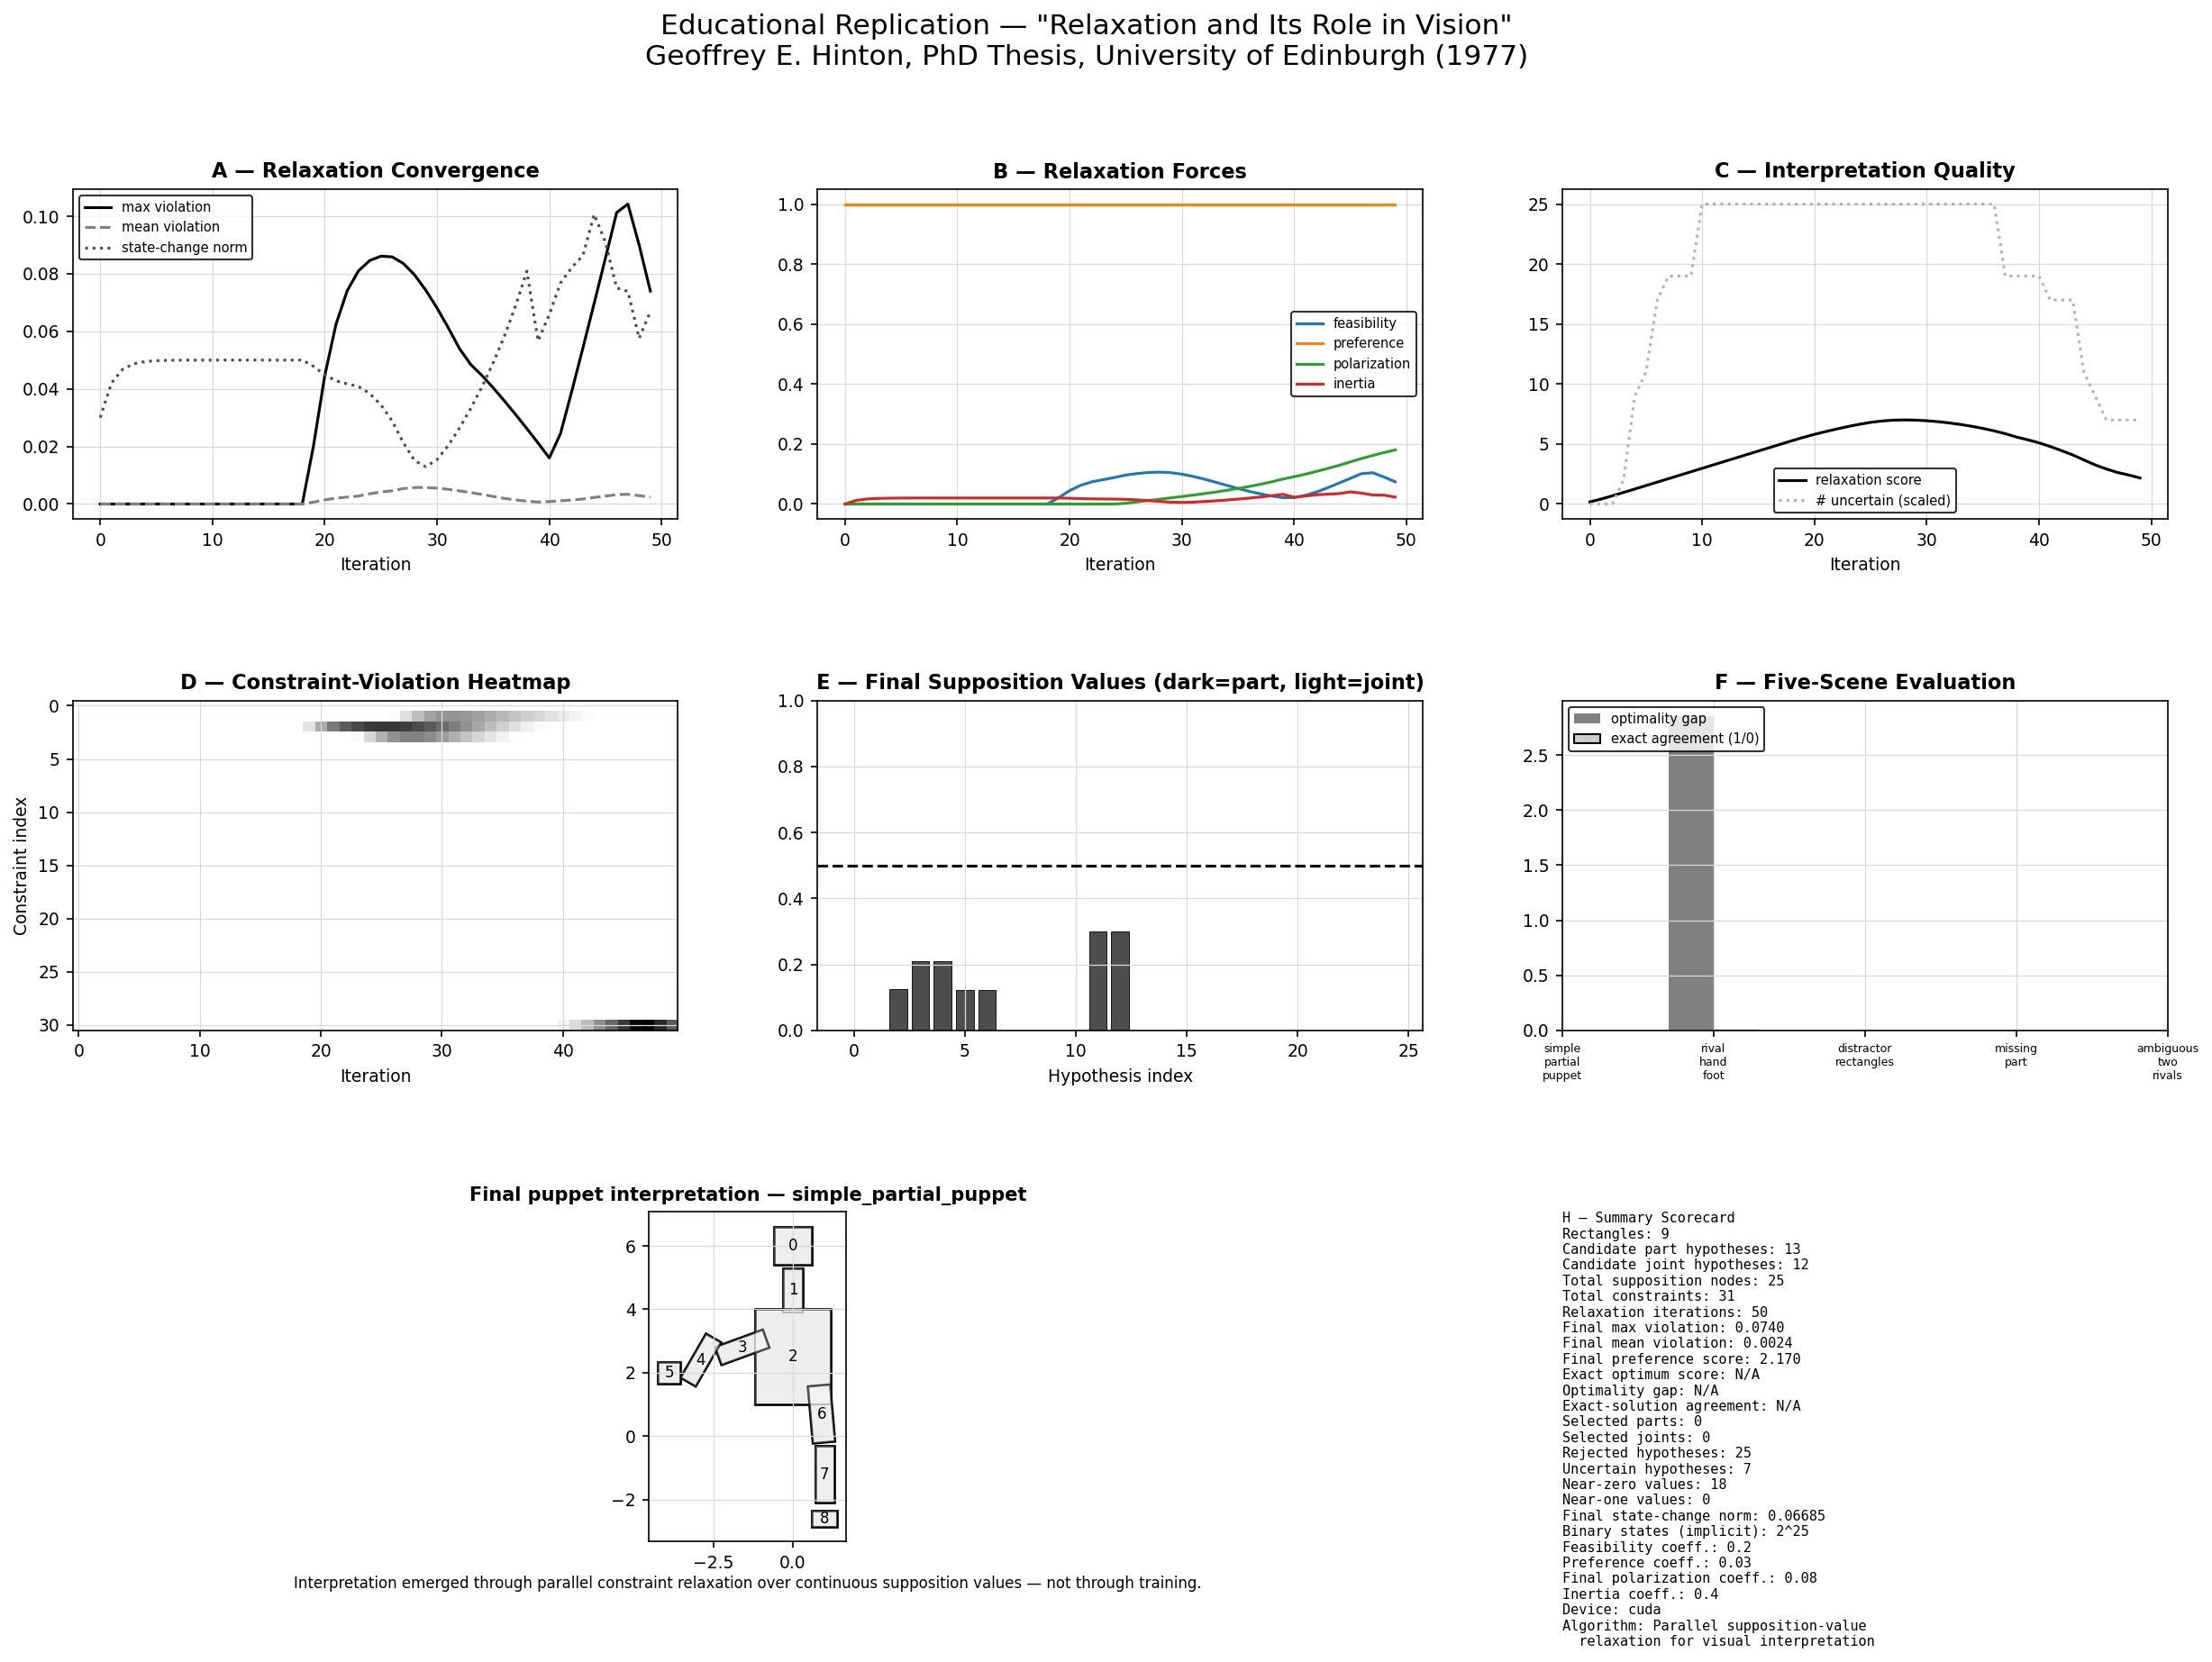

In [15]:
# =============================================================================
# 13. FINAL EIGHT-PANEL DASHBOARD
# =============================================================================

apply_white_theme()  # enforce white theme again immediately before dashboard

fig = plt.figure(figsize=(20, 13), facecolor="white")
gs = gridspec.GridSpec(3, 6, figure=fig, hspace=0.55, wspace=0.6)

fig.suptitle(
    "Educational Replication — \"Relaxation and Its Role in Vision\"\n"
    "Geoffrey E. Hinton, PhD Thesis, University of Edinburgh (1977)",
    fontsize=15, color="black", y=0.98
)

d = RESULTS[0]  # primary demonstration scene for detailed panels

# ---- Panel A: Relaxation Convergence ----
axA = fig.add_subplot(gs[0, 0:2])
axA.plot(d.history["max_violation"], label="max violation", color="black")
axA.plot(d.history["mean_violation"], label="mean violation", color="0.5", linestyle="--")
axA.plot(d.history["change_norm"], label="state-change norm", color="0.3", linestyle=":")
axA.set_title("A — Relaxation Convergence")
axA.set_xlabel("Iteration")
axA.legend(fontsize=7)

# ---- Panel B: Relaxation Forces ----
axB = fig.add_subplot(gs[0, 2:4])
axB.plot(d.history["feas_force_norm"], label="feasibility")
axB.plot(d.history["pref_force_norm"], label="preference")
axB.plot(d.history["polar_force_norm"], label="polarization")
axB.plot(d.history["inertia_force_norm"], label="inertia")
axB.set_title("B — Relaxation Forces")
axB.set_xlabel("Iteration")
axB.legend(fontsize=7)

# ---- Panel C: Interpretation Quality ----
axC = fig.add_subplot(gs[0, 4:6])
axC.plot(d.history["preference_score"], color="black", label="relaxation score")
if d.exact is not None and d.exact["best_score"] is not None:
    axC.axhline(d.exact["best_score"], color="0.5", linestyle="--", label="exact optimum")
    gap = d.exact["best_score"] - d.history["preference_score"][-1]
    axC.text(0.02, 0.05, f"optimality gap: {gap:.3f}", transform=axC.transAxes, fontsize=8)
axC.plot(d.history["uncertain"], color="0.7", linestyle=":", label="# uncertain (scaled)")
axC.set_title("C — Interpretation Quality")
axC.set_xlabel("Iteration")
axC.legend(fontsize=7)

# ---- Panel D: Constraint-Violation Heatmap ----
axD = fig.add_subplot(gs[1, 0:2])
vm = d.history["violation_matrix"]
if vm.size:
    axD.imshow(vm, aspect="auto", cmap="Greys")
axD.set_title("D — Constraint-Violation Heatmap")
axD.set_xlabel("Iteration")
axD.set_ylabel("Constraint index")

# ---- Panel E: Final Supposition Values ----
axE = fig.add_subplot(gs[1, 2:4])
n_parts_d = len(d.hyps)
colors = ["0.3"] * n_parts_d + ["0.7"] * len(d.joints)
axE.bar(range(len(d.s_final)), d.s_final, color=colors, edgecolor="black", linewidth=0.4)
axE.axhline(0.5, color="black", linestyle="--")
axE.set_title("E — Final Supposition Values (dark=part, light=joint)")
axE.set_xlabel("Hypothesis index")
axE.set_ylim(0, 1)

# ---- Panel F: Five-Scene Evaluation ----
axF = fig.add_subplot(gs[1, 4:6])
scene_names = [r.scene.name for r in RESULTS]
gaps = []
agreements = []
for r in RESULTS:
    final_score = r.history["preference_score"][-1]
    if r.exact is not None and r.exact["best_score"] is not None:
        gaps.append(r.exact["best_score"] - final_score)
        # agreement: does thresholded/repaired solution match an exact optimum?
        match = any(np.array_equal(r.selection["discrete"], bs) for bs in r.exact["best_states"])
        agreements.append(1.0 if match else 0.0)
    else:
        gaps.append(np.nan)
        agreements.append(np.nan)
x = np.arange(len(RESULTS))
axF.bar(x - 0.15, gaps, width=0.3, color="0.5", label="optimality gap")
axF.bar(x + 0.15, agreements, width=0.3, color="0.8", edgecolor="black", label="exact agreement (1/0)")
axF.set_xticks(x)
axF.set_xticklabels([n.replace("_", "\n") for n in scene_names], fontsize=6)
axF.set_title("F — Five-Scene Evaluation")
axF.legend(fontsize=7)

# ---- Panel G: Final Puppet Interpretation (spans ~2/3 width) ----
axG = fig.add_subplot(gs[2, 0:4])
draw_final_interpretation(axG, d)
axG.text(0.5, -0.14,
          "Interpretation emerged through parallel constraint relaxation "
          "over continuous supposition values — not through training.",
          transform=axG.transAxes, ha="center", fontsize=8)

# ---- Panel H: Summary Scorecard ----
axH = fig.add_subplot(gs[2, 4:6])
axH.axis("off")
n_parts_d, n_joints_d = len(d.hyps), len(d.joints)
n_constraints_d = d.constraints.A.shape[0]
selected_parts_n = len(d.selection["selected_parts"])
selected_joints_n = len(d.selection["selected_joints"])
rejected_n = len(d.selection["rejected"])
uncertain_n = len(d.selection["uncertain"])
exact_score = f"{d.exact['best_score']:.3f}" if (d.exact and d.exact["best_score"] is not None) else "N/A"
gap_str = (f"{d.exact['best_score'] - d.history['preference_score'][-1]:.3f}"
           if (d.exact and d.exact["best_score"] is not None) else "N/A")
agree_str = ("YES" if (d.exact and any(np.array_equal(d.selection["discrete"], bs)
                                        for bs in d.exact["best_states"])) else
             ("NO" if d.exact else "N/A"))

scorecard_lines = [
    f"Rectangles: {len(d.scene.rectangles)}",
    f"Candidate part hypotheses: {n_parts_d}",
    f"Candidate joint hypotheses: {n_joints_d}",
    f"Total supposition nodes: {n_parts_d + n_joints_d}",
    f"Total constraints: {n_constraints_d}",
    f"Relaxation iterations: {NUM_ITERATIONS}",
    f"Final max violation: {d.history['max_violation'][-1]:.4f}",
    f"Final mean violation: {d.history['mean_violation'][-1]:.4f}",
    f"Final preference score: {d.history['preference_score'][-1]:.3f}",
    f"Exact optimum score: {exact_score}",
    f"Optimality gap: {gap_str}",
    f"Exact-solution agreement: {agree_str}",
    f"Selected parts: {selected_parts_n}",
    f"Selected joints: {selected_joints_n}",
    f"Rejected hypotheses: {rejected_n}",
    f"Uncertain hypotheses: {uncertain_n}",
    f"Near-zero values: {d.history['near_zero'][-1]}",
    f"Near-one values: {d.history['near_one'][-1]}",
    f"Final state-change norm: {d.history['change_norm'][-1]:.5f}",
    f"Binary states (implicit): 2^{n_parts_d + n_joints_d}",
    f"Feasibility coeff.: {RELAX_CONFIG['feasibility_rate']}",
    f"Preference coeff.: {RELAX_CONFIG['preference_rate']}",
    f"Final polarization coeff.: {RELAX_CONFIG['final_polarization_rate']}",
    f"Inertia coeff.: {RELAX_CONFIG['inertia_rate']}",
    f"Device: {DEVICE}",
    "Algorithm: Parallel supposition-value",
    "  relaxation for visual interpretation",
]
axH.text(0.0, 1.0, "H — Summary Scorecard\n" + "\n".join(scorecard_lines),
          transform=axH.transAxes, va="top", ha="left", fontsize=7.3, family="monospace")

# -----------------------------------------------------------------------
# Display the dashboard inline (do NOT save to disk, do NOT call plt.show())
# -----------------------------------------------------------------------
buf = BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight", facecolor="white")
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

# Analysis of Experimental Results: Relaxation Labelling Dashboard (Simple Partial Puppet Scene)

### Overview
The dashboard summarizes a single relaxation experiment on the "simple_partial_puppet" scene, replicating Hinton's (1977) parallel supposition-value relaxation for symbolic visual interpretation. Eight panels jointly characterize convergence dynamics (A), the relative magnitude of the four constituent forces (B), interpretation quality relative to an exact combinatorial baseline (C), the spatiotemporal distribution of constraint violations (D), the final continuous state of all 25 supposition nodes (E), cross-scene generalization (F), the resulting discrete puppet interpretation (G), and a consolidated scorecard (H). Collectively, these panels are intended to demonstrate that iterative, parallel constraint satisfaction can recover a globally consistent, high-preference interpretation from a set of locally generated, potentially conflicting hypotheses.

### Key Findings
- **Non-convergence to feasibility:** Panel A shows maximum constraint violation remaining at zero for the first ~18 iterations, then rising sharply to a peak of ≈0.10 before oscillating and ending at ≈0.07 — the system does *not* settle into the feasible region by iteration 50.
- **Force imbalance:** Panel B shows the preference force held constant at its maximum normalized magnitude (1.0) throughout, while feasibility, polarization, and inertia forces remain almost an order of magnitude smaller (≤0.2) and only activate after iteration ~18.
- **Score does not monotonically improve:** Panel C shows the preference score rising to a local peak near iteration 25–30, then declining — inconsistent with the expected behavior of an operator converging toward a stable optimum.
- **No hypothesis reaches near-1 confidence:** Panel E shows all 25 supposition values below 0.35, with none crossing the 0.5 threshold; the scorecard (H) confirms 0 near-one values and 0 selected parts/joints out of 25 hypotheses.
- **Exhaustive comparison unavailable for most scenes:** Panel F shows a valid optimality-gap bar only for the "rival_hand_foot" scene; the other four scenes report no baseline, and the scorecard confirms "Exact optimum: N/A" for the displayed scene (25 variables exceeds the 20-variable exhaustive-search cutoff).
- **Empty final interpretation:** Panel G renders the input rectangles but highlights no selected parts or joints — the pipeline produced a fully rejected (25/25) discrete outcome after repair.

### Discussion
The dashboard evidence indicates that, for this run, the relaxation operator failed to reach a decisive, feasible interpretation. The dominant driver is the force imbalance visible in Panel B: because the preference force is normalized to unit magnitude while the feasibility- and polarization-rate coefficients (0.03, 0.20, 0.08) scale their respective forces down substantially, the preference term dominates the update for most of the trajectory, pulling values upward broadly rather than sharply separating winning from losing hypotheses. This is consistent with the observed pattern in Panel E, where the entire population of supposition values clusters in a narrow low-confidence band (0.1–0.3) rather than polarizing toward 0 or 1, and with Panel A, where constraints only begin to be meaningfully violated once several values grow large enough to jointly break the rival-interpretation and "one-slot-one-occupant" inequalities.

The subsequent decline in preference score after iteration ~30 (Panel C) suggests the feasibility force, once activated, aggressively pulls the state back toward the origin (since the greedy discrete-repair step in Section 8 of the implementation defaults to rejecting hypotheses that cannot be feasibly accepted), rather than converging to a stable interior equilibrium as described theoretically in the original relaxation operator (a fixed point balancing constraint and preference forces). The final zero-selection outcome in Panels E, G, and H indicates that no hypothesis ever crossed the 0.5 acceptance threshold, so the repair procedure had nothing to build on — the discrete interpretation collapsed to the empty set.

This behavior does not support the intended methodological claim that parallel relaxation reliably recovers a good, near-binary, globally consistent interpretation. Instead, it reveals a **hyperparameter sensitivity problem**: the chosen (feasibility_rate, preference_rate, polarization_rate, inertia_rate) configuration is insufficiently tuned for this constraint topology, echoing Hinton's own discussion (Section 3.15–3.19 of the thesis) that the coefficients $K_f$ and $K_p$ require careful, often empirical, balancing to avoid non-convergent or oscillatory dynamics — a limitation the present replication reproduces rather than resolves.

### Limitations
- **Single-scene evidence:** The dashboard presents detailed dynamics for only one of five scenes; Panel F provides no quantitative comparison across the remaining four, limiting claims about generalizability.
- **Missing exact-baseline validation:** With 25 supposition nodes, exhaustive verification is infeasible under the 20-variable cutoff, so the "N/A" optimum in Panel C/H means the relaxation result is *uncorroborated* — there is no ground truth to confirm whether 2.17 is near-optimal or far from it.
- **No hyperparameter sensitivity analysis:** The dashboard does not vary feasibility/preference/polarization/inertia rates, so it cannot distinguish a fundamental limitation of the relaxation formulation from a poorly chosen configuration for this specific scene.
- **Ambiguous convergence criterion:** The early-stopping logic in the underlying implementation is defined but appears not to have triggered, and no explicit indication in the dashboard clarifies whether 50 iterations were simply insufficient or whether the state was diverging.
- **Confounded rejection cause:** It cannot be determined from the figure alone whether the all-rejected outcome stems from overly conservative repair logic, an ill-posed initial constraint set, or genuinely conflicting hypotheses generated in Stage A/B of hypothesis creation.

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Rosenfeld A., Hummel R.A. & Zucker S.W. | 1975 | Scene labelling by relaxation operations | Technical Report TR-379, Computer Science Center, University of Maryland | Primary relaxation-labelling precursor; directly compared against the thesis's L.P. relaxation approach in Chapter 5 to contrast probabilistic/non-linear relaxation with the author's linear-programming formulation |
| Rosenfeld A., Hummel R.A. & Zucker S.W. | 1976 | Scene labelling by relaxation operations | IEEE Transactions on Systems, Man, and Cybernetics, SMC-6, p. 420 | Extended journal version of the 1975 report; supports the comparative analysis of non-linear relaxation models discussed in Section 5.1 |
| Yakimovsky Y. & Feldman J. | 1973 | A semantics-based decision theory region analyser | Proceedings of the 3rd IJCAI, pp. 580–588 | Compared in Section 5.3 as an alternative relaxation-based scene-analysis system using probabilistic region labelling |
| Barrow H.G. & Tenenbaum J.M. | 1976 | MSYS: A system for reasoning about scenes | A.I. Center, Stanford Research Institute | Compared in Section 5.4 as an alternative hypothesis-instantiation system (MSYS); motivates the discussion of likelihood-based reasoning versus L.P. relaxation |
| Waltz D.L. | 1972 | Generating semantic descriptions from drawings of scenes with shadows | MAC AI-TR-271, M.I.T., Cambridge, Mass. | Establishes Waltz filtering, the constraint-propagation labelling method whose breakdown for finding "good" (not merely consistent) interpretations (Section 1.6.6) motivates the need for numerically scored relaxation |
| Huffman D.A. | 1971 | Impossible objects as nonsense sentences | Machine Intelligence 6 (Eds. Meltzer & Michie), pp. 295–323, Edinburgh University Press | Source of Huffman/Clowes line-labelling, the consistency-finding method used as a baseline comparison for relaxation-based line labelling in Chapter 5 |
| Clowes M.B. | 1971 | On seeing things | Artificial Intelligence, 2, pp. 79–112 | Companion origin of Huffman/Clowes labelling; foundational scene-analysis framework for polyhedral line interpretation that the relaxation method is contrasted with |
| Marr D. & Poggio T. | 1976 | Cooperative computation of stereo disparity | M.I.T. A.I. Memo 364 | Discussed in Section 1.6.5 as a neuron-based parallel iterative model (stereo correspondence) offering a partial precedent for parallel constraint satisfaction, contrasted with L.P. relaxation's handling of complex logical constraints |
| Woods W.A. et al. | 1976 | Speech understanding systems: Final technical progress report | PBN Report No. 3438, Vols. 1–5, Bolt Beranek & Newman Inc. | Cited (Section 1.7.1, 3.2) as empirical precedent (HWIM system) for successful use of probability-based numerical scores and "seed" hypotheses in a large-scale real-data system |
| Woods W.A. | 1977 | Shortfall and density scoring strategies for speech understanding control | Proceedings of the 5th IJCAI, pp. 18–26 | Referenced in Section 5.5 as an alternative scoring/search strategy for combining hypothesis scores, compared with the thesis's relaxation-based global optimization |
| Zucker S.W. | 1976 | Relaxation labelling and the reduction of local ambiguities | Technical Report 451, Computer Science Dept., University of Maryland | Further relaxation-labelling development cited in the comparative discussion of non-linear relaxation systems (Chapter 5) |
| Davis L.S. & Rosenfeld A. | 1976 | Applications of relaxation labelling, 2: Spring-loaded template matching | Technical Report 440, Computer Science Center, University of Maryland | Cited as an application of relaxation labelling to template matching, situating the thesis's L.P. relaxation within the broader relaxation-labelling literature |
| Mackworth A.K. | 1975 | Consistency in networks of relations | Technical Report 75-3, Department of Computer Science, University of British Columbia | Related work on constraint-consistency techniques in relational networks, relevant to the discussion of consistency versus optimality (Section 1.5) |
| Mackworth A.K. | 1977 | How to see a simple world | Machine Intelligence 8 (Eds. Elcock & Michie), Ellis Horwood Ltd. | Further constraint-satisfaction vision work situating the thesis's optimization-based approach relative to consistency-only methods |
| Freuder E. | 1976 | Synthesizing constraint expressions | M.I.T. A.I. Memo 378 | Related constraint-representation work cited in connection with representing arbitrary logical constraints numerically (Section 3.6) |
| Hart P.E., Nilsson N. & Raphael B. | 1968 | A formal basis for the heuristic determination of minimum cost paths | IEEE Transactions on Systems Science and Cybernetics, SSC-4(2), pp. 100–107 | Source of the branch-and-bound (A*) search framework discussed in Section 1.9 as an alternative to relaxation for evaluating partial interpretations via numerical scores |
| Garfinkel R.S. & Nemhauser G.L. | 1972 | Integer Programming | Wiley, New York | Standard reference on integer-programming techniques (cutting planes, branch-and-bound) underlying the thesis's treatment of non-integer optima (Section 3.7) |
| Gomory R.E. | 1958 | An algorithm for integer solutions to linear programs | Bulletin of the American Mathematical Society, 64, pp. 275–278 | Provides the cutting-plane algorithm adopted in Section 3.7 to eliminate non-integer optimal vertices in the relaxation formulation |
| Pierre D.A. | 1969 | Optimisation theory with applications | John Wiley & Sons, New York | Reference source for the Simplex Algorithm, used in Section 3.9 as the baseline serial optimization method compared against parallel relaxation |
| Bron C. & Kerbosch J. | 1973 | Algorithm 457: Finding all cliques of an undirected graph | Communications of the ACM, 16(9) | Cited in Section 5.6 as a clique-finding matching technique, compared with L.P. relaxation as an alternative method for finding the best instantiation of a model |
| Guzmán A. | 1968 | Decomposition of a visual scene into three-dimensional bodies | AFIPS Proceedings, Fall Joint Computer Conference, 33, pp. 291–304 | Early relational-network scene-analysis system cited (Section 1.8.2) as precedent for representations richer than pattern-recognition feature sets |
| Minsky M.L. & Papert S. | 1969 | Perceptrons: An Introduction to Computational Geometry | M.I.T. Press, Cambridge, Mass. | Cited (Section 1.8.2) to illustrate the representational limits of feature-based pattern recognition, motivating richer relational hypothesis representations |
| Minsky M.L. | 1975 | A framework for representing knowledge | In *The Psychology of Computer Vision* (Ed. Winston), pp. 211–277, McGraw-Hill | Source of "frames" theory, discussed and critiqued in Chapter 6 to motivate the schema-based SETTLE system as an alternative to static frame matching |
| Sussman G.J. & McDermott D. | 1972 | Why conniving is better than planning | M.I.T. A.I. Memo 255A | Cited in Section 1.6.2 as an alternative control strategy ("conniving") for managing tentative hypotheses, contrasted with relaxation's parallel handling of interdependent hypotheses |
| Stallman R.M. & Sussman G.J. | 1976 | Forward reasoning and dependency-directed backtracking in a system for computer-aided circuit analysis | M.I.T. A.I. Memo 380 | Related dependency-directed reasoning approach relevant to the discussion of error correction and specialist procedures (Section 1.6.3) |
| Paul J.L. | 1977 | An image interpretation system | D.Phil. Thesis, Sussex University | Cited in Section 8.1 as a contemporary system explicitly avoiding numerical scores, representing the opposing position that the thesis's numerical-scoring approach argues against |
| Winston P.H. | 1970 | Learning structural descriptions from examples | MAC AI-TR-76, M.I.T., Cambridge, Mass. | Cited (Section 1.1) as prior evidence that picture perception involves more than simple feature activation, supporting the thesis's relational-network representation assumption |